# From masks to polygons with GeoPandas

`pyslyde.tools` converts raster masks into vector polygons in a
[GeoPandas](https://geopandas.org) `GeoDataFrame`, with area, perimeter and centroid for each
region. Vector polygons are convenient for spatial queries, measurements and exporting
regions to other tools (QuPath, GIS software, ...).

This notebook uses the PySlyde [example dataset](https://pyslyde.readthedocs.io/en/latest/example_data.html)
(CC0 OpenSlide slide plus *synthetic* `tissue` / `epithelium` annotations). It needs the
optional `geospatial` dependencies (`pip install "pyslyde[geospatial]"`: geopandas, shapely, rasterio).

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ["jpeg"]
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi

from pyslyde import Slide
from pyslyde.datasets import example_data_dir
from pyslyde.tools import polygons_from_mask, preprocess_mask

plt.rcParams["figure.dpi"] = 80

DATA_DIR = example_data_dir()            # honours $PYSLYDE_DATA_DIR
WSI_PATH = next((DATA_DIR / "wsi").iterdir())
OUTPUT_DIR = Path("geopandas_output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. An annotation mask

{'epithelium': 1, 'tissue': 2}


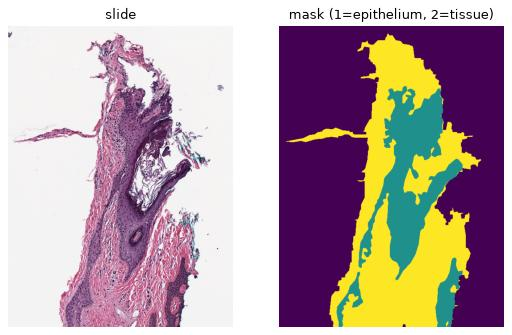

In [2]:
slide = Slide(str(WSI_PATH), annotations_path=str(DATA_DIR / "annotations" / "example.geojson"),
              source="geojson")
print(slide.annotations.class_key)

SIZE = (555, 742)                       # (width, height), 1/4 of level 0
mask = slide.generate_mask(size=SIZE)
thumb = np.array(slide.get_thumbnail(SIZE).convert("RGB"))

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(thumb); axes[0].set_title("slide")
axes[1].imshow(mask, cmap="viridis"); axes[1].set_title("mask (1=epithelium, 2=tissue)")
for ax in axes: ax.axis("off")
plt.show()

## 2. Pre-processing

`preprocess_mask` keeps the pixels of class 2 (here `tissue`) and fills holes inside them,
returning a binary mask:

uint8 [0 1]


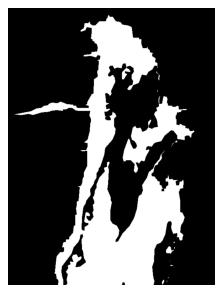

In [3]:
tissue = preprocess_mask(mask)
print(tissue.dtype, np.unique(tissue))
plt.figure(figsize=(3.5, 4.5)); plt.imshow(tissue, cmap="gray"); plt.axis("off"); plt.show()

## 3. Polygons

`polygons_from_mask` takes a *labelled* mask (one integer per region, 0 = background) and returns
one polygon per region (the convex hull of its contour). Invalid polygons are split using a
watershed on the distance transform. Every contour becomes a polygon, so small holes inside a
region produce small extra polygons. Here every connected epithelium region gets its own label.

The coordinates are pixels, but `polygons_from_mask` labels the result with a geographic CRS
(EPSG:4326). We drop that CRS so GeoPandas treats the coordinates as plain planar pixels.

In [4]:
epithelium_labels, n = ndi.label(mask == slide.annotations.class_key["epithelium"])
print(n, "epithelium regions")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS")
    gdf = polygons_from_mask(epithelium_labels)
gdf = gdf.set_crs(None, allow_override=True)
gdf[["area", "perimeter"]].round(1)

3 epithelium regions


,area,perimeter
0,79624.5,1199.8
1,382.0,81.0
2,55.0,34.7
3,7429.5,400.3
4,37.0,27.7
5,4748.0,319.9


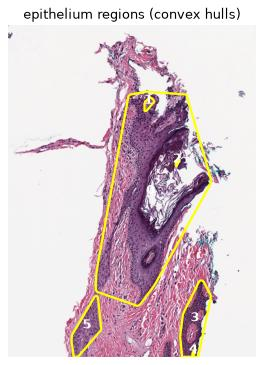

In [5]:
fig, ax = plt.subplots(figsize=(4, 5.4))
ax.imshow(thumb)
gdf.boundary.plot(ax=ax, color="yellow", linewidth=2)
for i, c in enumerate(gdf.centroid):
    ax.annotate(str(i), (c.x, c.y), color="white", ha="center", fontsize=12, weight="bold")
ax.set_title("epithelium regions (convex hulls)"); ax.axis("off")
plt.show()

Coordinates are in mask pixels. Scale them back to level-0 slide pixels before exporting, so
the polygons line up with the slide in other software:

In [6]:
from shapely import affinity

scale = slide.dims[0] / SIZE[0]
gdf_level0 = gdf.set_geometry(gdf.geometry.apply(
    lambda g: affinity.scale(g, xfact=scale, yfact=scale, origin=(0, 0))
))[["geometry"]]
gdf_level0["area_px"] = gdf_level0.area
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="'crs' was not provided")  # pixel coordinates
    gdf_level0.to_file(OUTPUT_DIR / "epithelium_regions.geojson", driver="GeoJSON")
gdf_level0.round(0)

,geometry,area_px
0,"POLYGON ((1236 592, 1096 616, 1084 624, 1076 6...",1273992.0
1,"POLYGON ((1268 640, 1224 684, 1220 692, 1220 7...",6112.0
2,"POLYGON ((1524 1196, 1500 1220, 1500 1248, 150...",880.0
3,"POLYGON ((1728 2280, 1716 2284, 1708 2292, 157...",118872.0
4,"POLYGON ((1664 2912, 1656 2920, 1648 2932, 164...",592.0
5,"POLYGON ((788 2420, 776 2424, 772 2428, 572 27...",75968.0


## Next steps

* [PySlyde tutorial](pyslyde_tutorial.ipynb) - the full slide → tiles → features workflow
* [API reference for `pyslyde.tools`](https://pyslyde.readthedocs.io/en/latest/api/generated/pyslyde.tools.html)